# CSC428 Final Project — ML Side-Channel Attack on AES (ASCAD)

**Suwan Aryal** & **Kapil Sharma**

##### Single-trace classification: from one 700-sample power trace recorded during a masked-AES execution, predict the Hamming weight (0–8) of the masked S-box output.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import numpy as np
import pandas as pd

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings

warnings.filterwarnings('ignore')

In [2]:
#Download Data into data/

dataset_url = 'https://www.data.gouv.fr/api/1/datasets/r/e7ab6f9e-79bf-431f-a5ed-faf0ebe9b08e'
#dataset is 4GiB compressed and 8GiB when extracted.

In [6]:
#exploring all available data

HW_TABLE = np.array([bin(i).count('1') for i in range(256)], dtype=np.int64)

with h5py.File('data/ASCAD.h5', 'r') as f:
    traces = np.concatenate([
        np.array(f['Profiling_traces/traces'], dtype=np.float32),
        np.array(f['Attack_traces/traces'],     dtype=np.float32),
    ], axis=0)
    sbox_unmasked = np.concatenate([
        np.array(f['Profiling_traces/labels'], dtype=np.int64),
        np.array(f['Attack_traces/labels'],     dtype=np.int64),
    ], axis=0)
    masks = np.concatenate([
        np.array(f['Profiling_traces/metadata']['masks'], dtype=np.int64),
        np.array(f['Attack_traces/metadata']['masks'],     dtype=np.int64),
    ], axis=0)

n, n_samples = traces.shape
print(f'combined: {n:,} traces  ×  {n_samples} samples each')
print(f'mask bytes per trace: {masks.shape[1]} \n')

feature_cols = [f't_{i}' for i in range(n_samples)]
df = pd.DataFrame(traces, columns=feature_cols)
df['label'] = -1

df[feature_cols[:5] + ['label']].head()

combined: 60,000 traces  ×  700 samples each
mask bytes per trace: 16 



,t_0,t_1,t_2,t_3,t_4,label
0,20.0,19.0,13.0,6.0,-2.0,-1
1,22.0,20.0,15.0,8.0,-1.0,-1
2,24.0,22.0,18.0,12.0,3.0,-1
3,24.0,23.0,18.0,11.0,2.0,-1
4,21.0,20.0,16.0,9.0,1.0,-1


In [7]:
df[feature_cols[::100]].describe().round(2)

,t_0,t_100,t_200,t_300,t_400,t_500,t_600
count,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00,60000.00
mean,20.00,1.20,10.25,-38.80,-33.82,-5.05,11.33
std,2.76,2.49,4.00,2.94,1.84,2.83,0.86
min,10.00,-9.00,-4.00,-47.00,-39.00,-14.00,8.00
25%,18.00,-1.00,7.00,-41.00,-35.00,-7.00,11.00
50%,20.00,1.00,10.00,-39.00,-34.00,-5.00,11.00
75%,22.00,3.00,13.00,-37.00,-32.00,-3.00,12.00
max,30.00,10.00,23.00,-29.00,-29.00,4.00,14.00


### What does a single power trace look like?


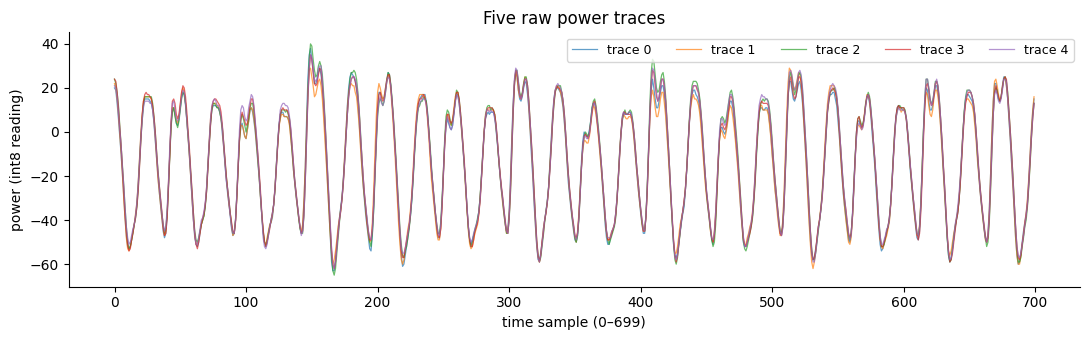

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.5))

for i in range(5):
    ax.plot(df.iloc[i, :n_samples].values, alpha=0.7, linewidth=0.9, label=f'trace {i}')

ax.set(title='Five raw power traces', xlabel='time sample (0–699)', ylabel='power (int8 reading)')
ax.legend(loc='upper right', ncol=5, fontsize=9)
sns.despine()

plt.tight_layout()
plt.show()

## Data cleaning + label engineering


In [9]:
#Some help with GenAI was used to understand SNR and the traces labels.

Path('results').mkdir(exist_ok=True)

trace_block = df[feature_cols].values

def per_sample_snr(traces, labels, n_classes=9):
    means = np.zeros((n_classes, traces.shape[1]), dtype=np.float64)
    var_w = np.zeros_like(means)
    counts = np.zeros(n_classes, dtype=np.int64)
    for c in range(n_classes):
        sl = labels == c
        n = int(sl.sum())
        counts[c] = n
        if n == 0:
            continue
        sub = traces[sl].astype(np.float64)
        means[c] = sub.mean(axis=0)
        var_w[c] = sub.var(axis=0)
    grand = (means * counts[:, None]).sum(0) / counts.sum()
    w = counts[:, None] / counts.sum()
    var_b = ((means - grand) ** 2 * w).sum(0)
    return var_b / np.maximum((var_w * w).sum(0), 1e-12)

N_DIAG = min(10000, len(df))

snr_per_mask = []

for m_idx in range(masks.shape[1]):
    cand = HW_TABLE[(sbox_unmasked[:N_DIAG] ^ masks[:N_DIAG, m_idx]) & 0xff]
    snr_per_mask.append(per_sample_snr(trace_block[:N_DIAG], cand).max())

snr_per_mask = np.array(snr_per_mask)
best_mask = int(snr_per_mask.argmax())
snr_unmasked = per_sample_snr(trace_block[:N_DIAG], HW_TABLE[sbox_unmasked[:N_DIAG]])

print(f'\nper-mask peak SNR: {snr_per_mask.round(4).tolist()}')
print(f'best mask byte: index {best_mask}  (SNR {snr_per_mask[best_mask]:.3f}  vs unmasked SNR {snr_unmasked.max():.4f})')

df['label'] = HW_TABLE[(sbox_unmasked ^ masks[:, best_mask]) & 0xff]


per-mask peak SNR: [2.3975, 0.0022, 0.0025, 0.0027, 0.0018, 0.002, 0.0027, 0.0018, 0.0023, 0.0029, 0.0019, 0.002, 0.0016, 0.0017, 0.0016, 0.7496]
best mask byte: index 0  (SNR 2.398  vs unmasked SNR 0.0016)


In [10]:
scaler = StandardScaler().fit(trace_block)
df.loc[:, feature_cols] = scaler.transform(trace_block).astype(np.float32)

df[feature_cols[:5] + ['label']].head()

,t_0,t_1,t_2,t_3,t_4,label
0,0.001197,-0.078282,-0.636581,-0.732540,-0.826785,2
1,0.726403,0.272026,0.003108,-0.117589,-0.509328,7
2,1.451610,0.972643,0.962641,1.112313,0.760500,5
3,1.451610,1.322952,0.962641,0.804837,0.443043,4
4,0.363800,0.272026,0.322952,0.189887,0.125586,4


## Train-test split via stratified 5-fold cross-validation



In [11]:

X_all = df[feature_cols].values.astype(np.float32)
y_all = df['label'].values.astype(np.int64)
print(f'X_all: {X_all.shape}   y_all: {y_all.shape}')

K = 5
kfold = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

fold_sizes = []
for i, (tr, te) in enumerate(kfold.split(X_all, y_all)):
    fold_sizes.append((i + 1, len(tr), len(te)))
    print(f'  fold {i+1}: train={len(tr):>5d}   test={len(te):>5d}')

fold_df = pd.DataFrame(fold_sizes, columns=['fold', 'train_size', 'test_size'])

X_all: (60000, 700)   y_all: (60000,)
  fold 1: train=48000   test=12000
  fold 2: train=48000   test=12000
  fold 3: train=48000   test=12000
  fold 4: train=48000   test=12000
  fold 5: train=48000   test=12000


## Models define, train, test with k-fold CV


In [12]:
# Using A100 GPU on Google Colab:

INPUT_LEN = X_all.shape[1]
N_CLASSES = 9
EPOCHS    = 100
BATCH     = 256

def early_stop():
    return keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=0,
    )

def build_logreg():

    m = keras.Sequential([
        layers.Input(shape=(INPUT_LEN,)),
        layers.Dense(N_CLASSES, activation='softmax'),
        ],
        name='logreg')

    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_mlp():
    m = keras.Sequential([
        layers.Input(shape=(INPUT_LEN,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(N_CLASSES, activation='softmax'),
        ],
         name='mlp')

    m.compile(optimizer=keras.optimizers.RMSprop(1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn():
    m = keras.Sequential([
        layers.Input(shape=(INPUT_LEN, 1)),
        layers.Conv1D(32, 11, activation='relu', padding='same'),
        layers.AveragePooling1D(2),
        layers.Conv1D(64, 11, activation='relu', padding='same'),
        layers.AveragePooling1D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(N_CLASSES, activation='softmax'),
    ], name='cnn')

    m.compile(optimizer=keras.optimizers.RMSprop(1e-4),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

all_preds = {}

def kfold_cv(builder, X, y, channel=False, name=''):

    accs = []
    y_true_all, y_pred_all = [], []

    for fold_idx, (tr_idx, te_idx) in enumerate(kfold.split(X, y)):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]

        n_val = max(1, len(X_tr) // 9)

        X_inner_tr, X_val = X_tr[:-n_val], X_tr[-n_val:]
        y_inner_tr, y_val = y_tr[:-n_val], y_tr[-n_val:]

        if channel:
            X_inner_tr, X_val, X_te = X_inner_tr[..., None], X_val[..., None], X_te[..., None]

        model = builder()

        model.fit(X_inner_tr, y_inner_tr, validation_data=(X_val, y_val),
                  epochs=EPOCHS, batch_size=BATCH, verbose=0,
                  callbacks=[early_stop()])

        _, acc = model.evaluate(X_te, y_te, batch_size=512, verbose=0)
        preds = model.predict(X_te, batch_size=512, verbose=0).argmax(axis=1)
        y_true_all.append(y_te); y_pred_all.append(preds)

        accs.append(acc)

        print(f'  fold {fold_idx+1}/{K}: test_acc = {acc:.4f}')
    if name:
        all_preds[name] = (np.concatenate(y_true_all), np.concatenate(y_pred_all))
    return np.array(accs)

results = {}
majority_class = int(np.bincount(y_all, minlength=9).argmax())

results['Majority-class baseline'] = np.full(K, float((y_all == majority_class).mean()))
print(f"majority-class: always predict HW={majority_class}): {results['Majority-class baseline'][0]:.4f}")

majority-class: always predict HW=4): 0.2749


### Logistic Regression

In [13]:
print('Logistic Regression Results:')

results['Logistic Regression'] = kfold_cv(build_logreg, X_all, y_all, name='Logistic Regression')
print(f"  mean test_acc = {results['Logistic Regression'].mean():.4f}  ±  {results['Logistic Regression'].std():.4f}")

Logistic Regression Results:
  fold 1/5: test_acc = 0.5823
  fold 2/5: test_acc = 0.5903
  fold 3/5: test_acc = 0.5868
  fold 4/5: test_acc = 0.5899
  fold 5/5: test_acc = 0.5889
  mean test_acc = 0.5877  ±  0.0029


### MLP

In [14]:
print('MLP Results:')

results['MLP'] = kfold_cv(build_mlp, X_all, y_all, name='MLP')
print(f"  mean test_acc = {results['MLP'].mean():.4f}  ±  {results['MLP'].std():.4f}")

MLP Results:
  fold 1/5: test_acc = 0.6074
  fold 2/5: test_acc = 0.6132
  fold 3/5: test_acc = 0.6094
  fold 4/5: test_acc = 0.6037
  fold 5/5: test_acc = 0.6132
  mean test_acc = 0.6094  ±  0.0036


### CNN

In [15]:
print('CNN Results:')

results['CNN'] = kfold_cv(build_cnn, X_all, y_all, name='CNN')
print(f"  mean test_acc = {results['CNN'].mean():.4f}  ±  {results['CNN'].std():.4f}")

CNN Results:
  fold 1/5: test_acc = 0.6102
  fold 2/5: test_acc = 0.6137
  fold 3/5: test_acc = 0.6062
  fold 4/5: test_acc = 0.6060
  fold 5/5: test_acc = 0.6021
  mean test_acc = 0.6076  ±  0.0040


## Results comparison

In [16]:
summary = pd.DataFrame({name: arr for name, arr in results.items()},
                       index=[f'fold_{i+1}' for i in range(K)])
summary.loc['mean'] = summary.iloc[:K].mean()
summary.loc['std']  = summary.iloc[:K].std()

summary.round(4)

,Majority-class baseline,Logistic Regression,MLP,CNN
fold_1,0.2749,0.5823,0.6074,0.6102
fold_2,0.2749,0.5903,0.6132,0.6137
fold_3,0.2749,0.5868,0.6094,0.6062
fold_4,0.2749,0.5899,0.6037,0.6060
fold_5,0.2749,0.5889,0.6132,0.6021
mean,0.2749,0.5877,0.6094,0.6076
std,0.0000,0.0033,0.0040,0.0044


### Mean test accuracy ± std across folds

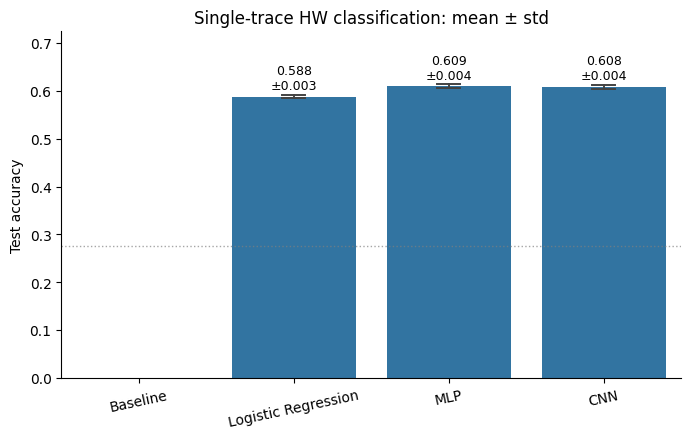

In [27]:
long = summary.iloc[:K].reset_index().melt(id_vars='index', var_name='model', value_name='test_acc').rename(columns={'index': 'fold'})

model_order = ['Baseline', 'Logistic Regression', 'MLP', 'CNN']

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=long, x='model', y='test_acc', order=model_order,
            errorbar='sd', capsize=0.15, errwidth=1.4, ax=ax)

for i, m in enumerate(model_order):
    mu = long[long.model == m]['test_acc'].mean()
    sd = long[long.model == m]['test_acc'].std()
    ax.text(i, mu + sd + 0.012, f'{mu:.3f}\n±{sd:.3f}', ha='center', fontsize=9)

ax.axhline(results['Majority-class baseline'][0], color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.set(title='Single-trace HW classification: mean ± std',
       xlabel='', ylabel='Test accuracy')

ax.set_ylim(0, max(long.test_acc) * 1.18)
plt.xticks(rotation=12)
sns.despine()

### Heatmap: every (model, fold) pair

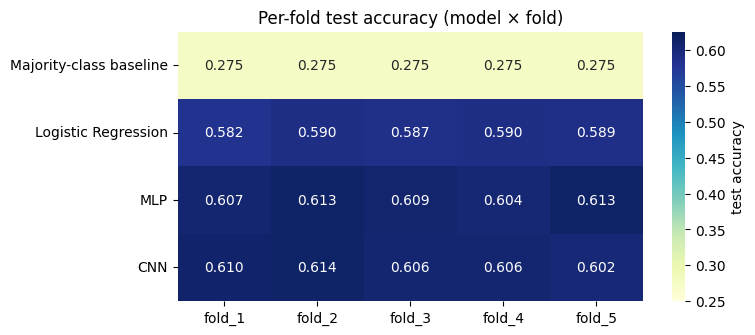

In [25]:
heatmap_data = summary.iloc[:K].T   # rows = models, cols = folds

fig, ax = plt.subplots(figsize=(7.5, 3.5))

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu',
            cbar_kws={'label': 'test accuracy'}, vmin=0.25, vmax=heatmap_data.values.max() * 1.02, ax=ax)

ax.set(title='Per-fold test accuracy (model × fold)', xlabel='', ylabel='')
plt.show()

### Confusion matrix


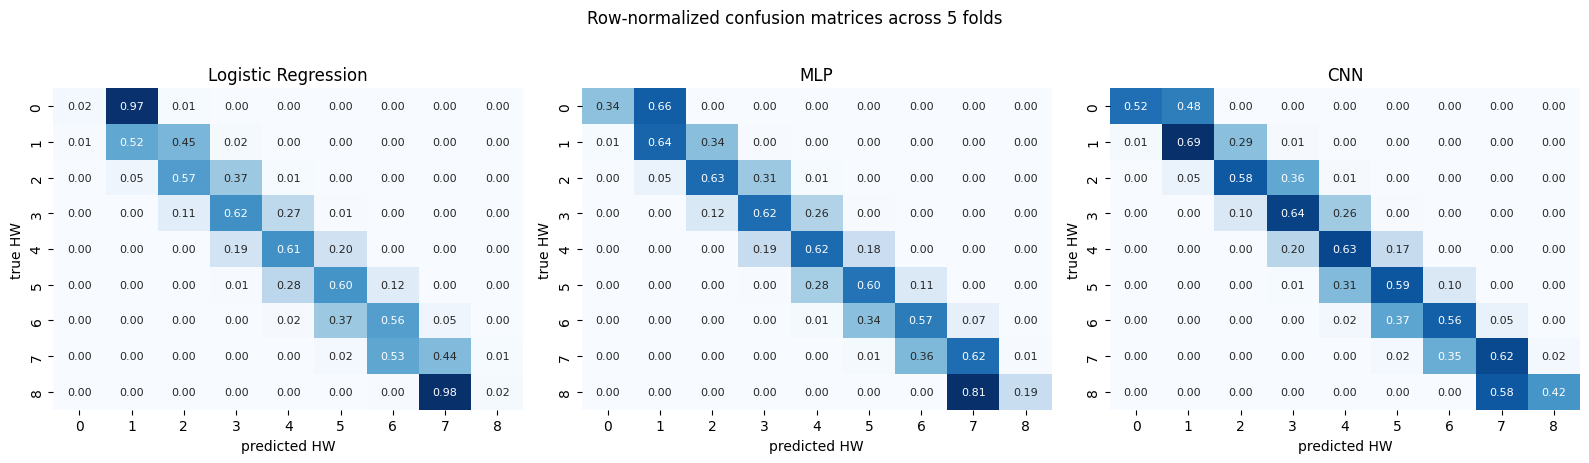

In [20]:
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, mname in zip(axes, ['Logistic Regression', 'MLP', 'CNN']):
    y_true, y_pred = all_preds[mname]

    cm = confusion_matrix(y_true, y_pred, labels=list(range(9)), normalize='true')

    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', cbar=False,
                xticklabels=range(9), yticklabels=range(9), ax=ax,
                annot_kws={'size': 8})
    ax.set(title=mname, xlabel='predicted HW', ylabel='true HW')

plt.suptitle('Row-normalized confusion matrices across 5 folds', y=1.02)
plt.tight_layout()

In [21]:
y_true, y_pred = all_preds['CNN']
report = classification_report(y_true, y_pred, labels=list(range(9)), output_dict=True, zero_division=0)
rep_df = pd.DataFrame(report).T.iloc[:9][['precision', 'recall', 'f1-score', 'support']]
rep_df.index.name = 'HW class'
rep_df.round(3)

,precision,recall,f1-score,support
HW class,,,,
0,0.840,0.518,0.641,253.0
1,0.747,0.686,0.716,1893.0
2,0.670,0.577,0.620,6579.0
3,0.588,0.639,0.613,13062.0
4,0.577,0.625,0.600,16493.0
5,0.590,0.586,0.588,13049.0
6,0.646,0.558,0.599,6521.0
7,0.718,0.620,0.666,1904.0
8,0.780,0.419,0.545,246.0


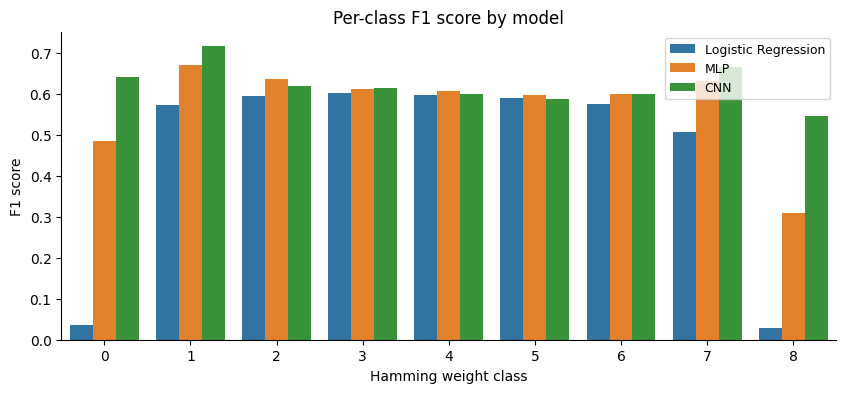

In [22]:
# Per-class F1 for all three models

rows = []
for mname in ['Logistic Regression', 'MLP', 'CNN']:
    y_true, y_pred = all_preds[mname]
    rep = classification_report(y_true, y_pred, labels=list(range(9)), output_dict=True, zero_division=0)

    for c in range(9):
        rows.append({'model': mname, 'HW class': c, 'F1': rep[str(c)]['f1-score']})
f1_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=f1_df, x='HW class', y='F1', hue='model', ax=ax)
ax.set(title='Per-class F1 score by model', ylabel='F1 score', xlabel='Hamming weight class')
ax.legend(loc='upper right', fontsize=9)
sns.despine()
